# 2D PINN: Glomerular Filtration Simulation
This notebook acts as an interactive walkthrough of the 2D Physics-Informed Neural Network (PINN) training and visualization. The core physics engine and neural network architecture are cleanly separated into the `src/` directory to maintain software engineering standards.

## 0. Environment Setup
Run this cell to ensure all required libraries are installed directly into the notebook's active kernel.

In [7]:
%pip install torch numpy matplotlib scipy --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from src.train import train_pinn

# display plots inline
%matplotlib inline


## 1. Normotensive State (Healthy Simulation)
We train the model with normal hydrostatic pressure ($u_{max}=1.0$) and a healthy filtration coefficient ($k=1.5$).

In [3]:
print("[+] Training Normotensive Model...")
model_healthy = train_pinn(epochs=6000, lr=1e-3, u_max=1.0, D=0.01, k=1.5)

[+] Training Normotensive Model...
Training 2D PINN on device: cpu
Epoch 00000 | Total: 52.7345 | Data: 0.2636 | Physics: 0.0046
Epoch 00500 | Total: 3.8732 | Data: 0.0171 | Physics: 0.4566
Epoch 01000 | Total: 1.3516 | Data: 0.0054 | Physics: 0.2658
Epoch 01500 | Total: 0.8047 | Data: 0.0033 | Physics: 0.1347
Epoch 02000 | Total: 0.6036 | Data: 0.0025 | Physics: 0.0946
Epoch 02500 | Total: 0.4722 | Data: 0.0020 | Physics: 0.0688
Epoch 03000 | Total: 0.3995 | Data: 0.0017 | Physics: 0.0599
Epoch 03500 | Total: 0.3217 | Data: 0.0014 | Physics: 0.0391
Epoch 04000 | Total: 0.2723 | Data: 0.0012 | Physics: 0.0347
Epoch 04500 | Total: 0.3844 | Data: 0.0017 | Physics: 0.0418
Epoch 05000 | Total: 0.4067 | Data: 0.0019 | Physics: 0.0342
Epoch 05500 | Total: 0.1939 | Data: 0.0008 | Physics: 0.0303


### Visualize Healthy Solute Clearance

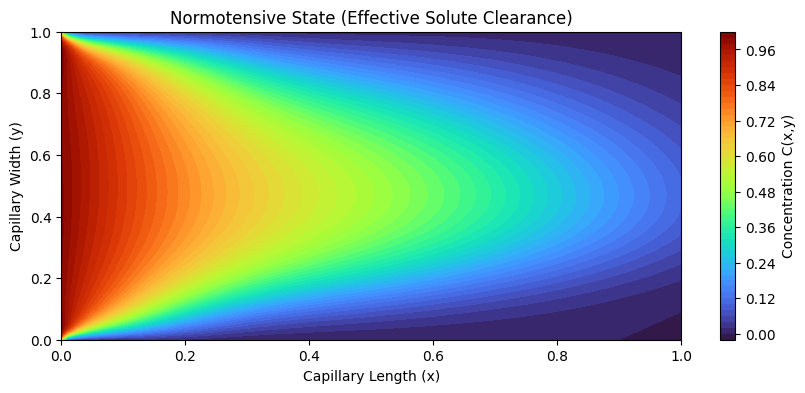

In [4]:
def plot_2d_snapshot(model, title):
    model.eval()
    x = np.linspace(0, 1, 100)
    y = np.linspace(0, 1, 100)
    X, Y = np.meshgrid(x, y)
    x_flat = torch.tensor(X.flatten()[:, None], dtype=torch.float32)
    y_flat = torch.tensor(Y.flatten()[:, None], dtype=torch.float32)
    t_flat = torch.ones_like(x_flat) # Snapshot at t=1.0
    
    with torch.no_grad():
        C_pred = model(x_flat, y_flat, t_flat).numpy()
        
    C_grid = C_pred.reshape(X.shape)
    
    plt.figure(figsize=(10, 4))
    contour = plt.contourf(X, Y, C_grid, 60, cmap='turbo')
    plt.colorbar(contour, label='Concentration C(x,y)')
    plt.xlabel('Capillary Length (x)')
    plt.ylabel('Capillary Width (y)')
    plt.title(title)
    plt.show()

plot_2d_snapshot(model_healthy, "Normotensive State (Effective Solute Clearance)")

## 2. Hypertensive State (Pathological Simulation)
We train the model with high hydrostatic pressure ($u_{max}=3.5$) and impaired filtration ($k=0.1$).

[+] Training Hypertensive Model...
Training 2D PINN on device: cpu
Epoch 00000 | Total: 51.6929 | Data: 0.2585 | Physics: 0.0010
Epoch 00500 | Total: 8.1025 | Data: 0.0361 | Physics: 0.8903
Epoch 01000 | Total: 8.6797 | Data: 0.0396 | Physics: 0.7641
Epoch 01500 | Total: 7.5077 | Data: 0.0334 | Physics: 0.8229
Epoch 02000 | Total: 4.3807 | Data: 0.0178 | Physics: 0.8126
Epoch 02500 | Total: 2.9003 | Data: 0.0121 | Physics: 0.4874
Epoch 03000 | Total: 2.0018 | Data: 0.0085 | Physics: 0.3077
Epoch 03500 | Total: 1.5610 | Data: 0.0065 | Physics: 0.2522
Epoch 04000 | Total: 1.3224 | Data: 0.0056 | Physics: 0.2068
Epoch 04500 | Total: 1.1327 | Data: 0.0047 | Physics: 0.1988
Epoch 05000 | Total: 0.9956 | Data: 0.0041 | Physics: 0.1702
Epoch 05500 | Total: 0.8982 | Data: 0.0038 | Physics: 0.1410


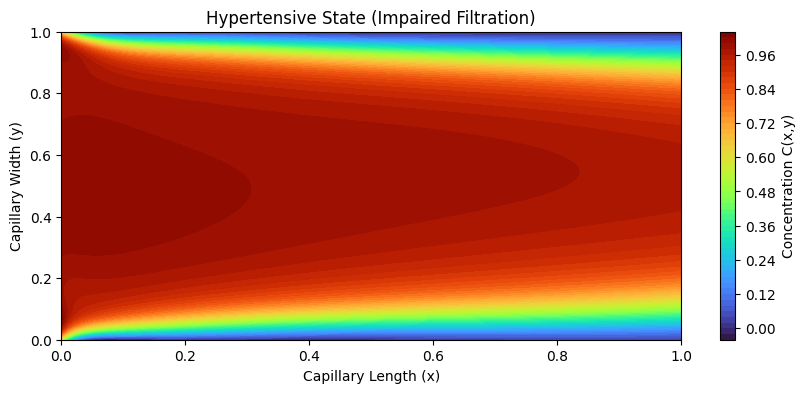

In [5]:
print("[+] Training Hypertensive Model...")
model_diseased = train_pinn(epochs=6000, lr=1e-3, u_max=3.5, D=0.01, k=0.1)

plot_2d_snapshot(model_diseased, "Hypertensive State (Impaired Filtration)")